In [11]:
import time
notebook_start = time.perf_counter()
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

from thermoift import FeedsBuilder
from itertools import combinations
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import thermoift.PLOT_SETTINGS as ps
import matplotlib.colors as mcolors

In [12]:
# ── Pool generation config ─────────────────────────────────────────────────
# Pool of 1000 compositions — subsets of 100, 200, … 500 are drawn in 02_GPR_AL
# to study how Random / Stratified / AL compare at increasing sample budgets.
M_COMPOSITIONS  = 1000

COMPONENTS      = ["CO2", "H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
CO2_LEVELS      = (0.95, 0.96, 0.97, 0.98, 0.99)
SEED            = 770077

# Dirichlet alpha — matches DATASET_A1/Feed.ipynb convention
ALPHA = {
    "N2":  5.0,
    "CH4": 5.0,
    "H2":  5.0,
    "Ar":  5.0,
    "O2":  0.1,
    "CO":  0.1,
    "H2S": 0.1,
}

OUTPUT_DIR = Path("POOL")
OUTPUT_DIR.mkdir(exist_ok=True)

In [13]:
builder = FeedsBuilder(rng_type="PCG64", seed=SEED)
builder.load_industrial_templates(Path("../DATASET_A1/IndustrialFeeds.json"))

# Same 70 / 20 / 10 split as Feed.ipynb — just at larger scale (M_COMPOSITIONS)
df_comp = builder.combine_feeds_random_systematic_industrial(
    components      = COMPONENTS,
    n_total_target  = M_COMPOSITIONS,
    co2_levels      = CO2_LEVELS,
    frac_random     = 0.70,
    frac_systematic = 0.20,
    frac_industrial = 0.10,
)

df_comp = df_comp.reset_index(drop=True)
df_comp.insert(0, "feed_id", df_comp.index)

print(f"Unique compositions : {len(df_comp):,}")
print(df_comp["feed_source"].value_counts())

Unique compositions : 1,000
feed_source
Random (Dirichlet)    700
Systematic            200
industrial_bound       60
industrial_range       40
Name: count, dtype: int64


In [14]:
# KIJ pairs config (all zero — same convention as DATASET_A1)
pairs     = [f"{a}-{b}" for a, b in combinations(COMPONENTS, 2)]
kij_pairs = {pair: "zero" for pair in pairs}

kij_file  = OUTPUT_DIR / "KIJ_pairs.json"
with open(kij_file, "w") as f:
    json.dump(kij_pairs, f, indent=2)
print(f"KIJ pairs saved to {kij_file}")

KIJ pairs saved to POOL/KIJ_pairs.json


In [15]:
pool_path = OUTPUT_DIR / "composition_pool.csv"
df_comp.to_csv(pool_path, index=False)
print(f"Pool saved: {pool_path}")
print(f"Shape : {df_comp.shape}")
print(f"Columns: {list(df_comp.columns)}")

Pool saved: POOL/composition_pool.csv
Shape : (1000, 13)
Columns: ['feed_id', 'feed_source', 'template_name', 'mixture_size', 'active_components', 'CO2', 'H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']


/tmp/ipykernel_371491/3435210569.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(


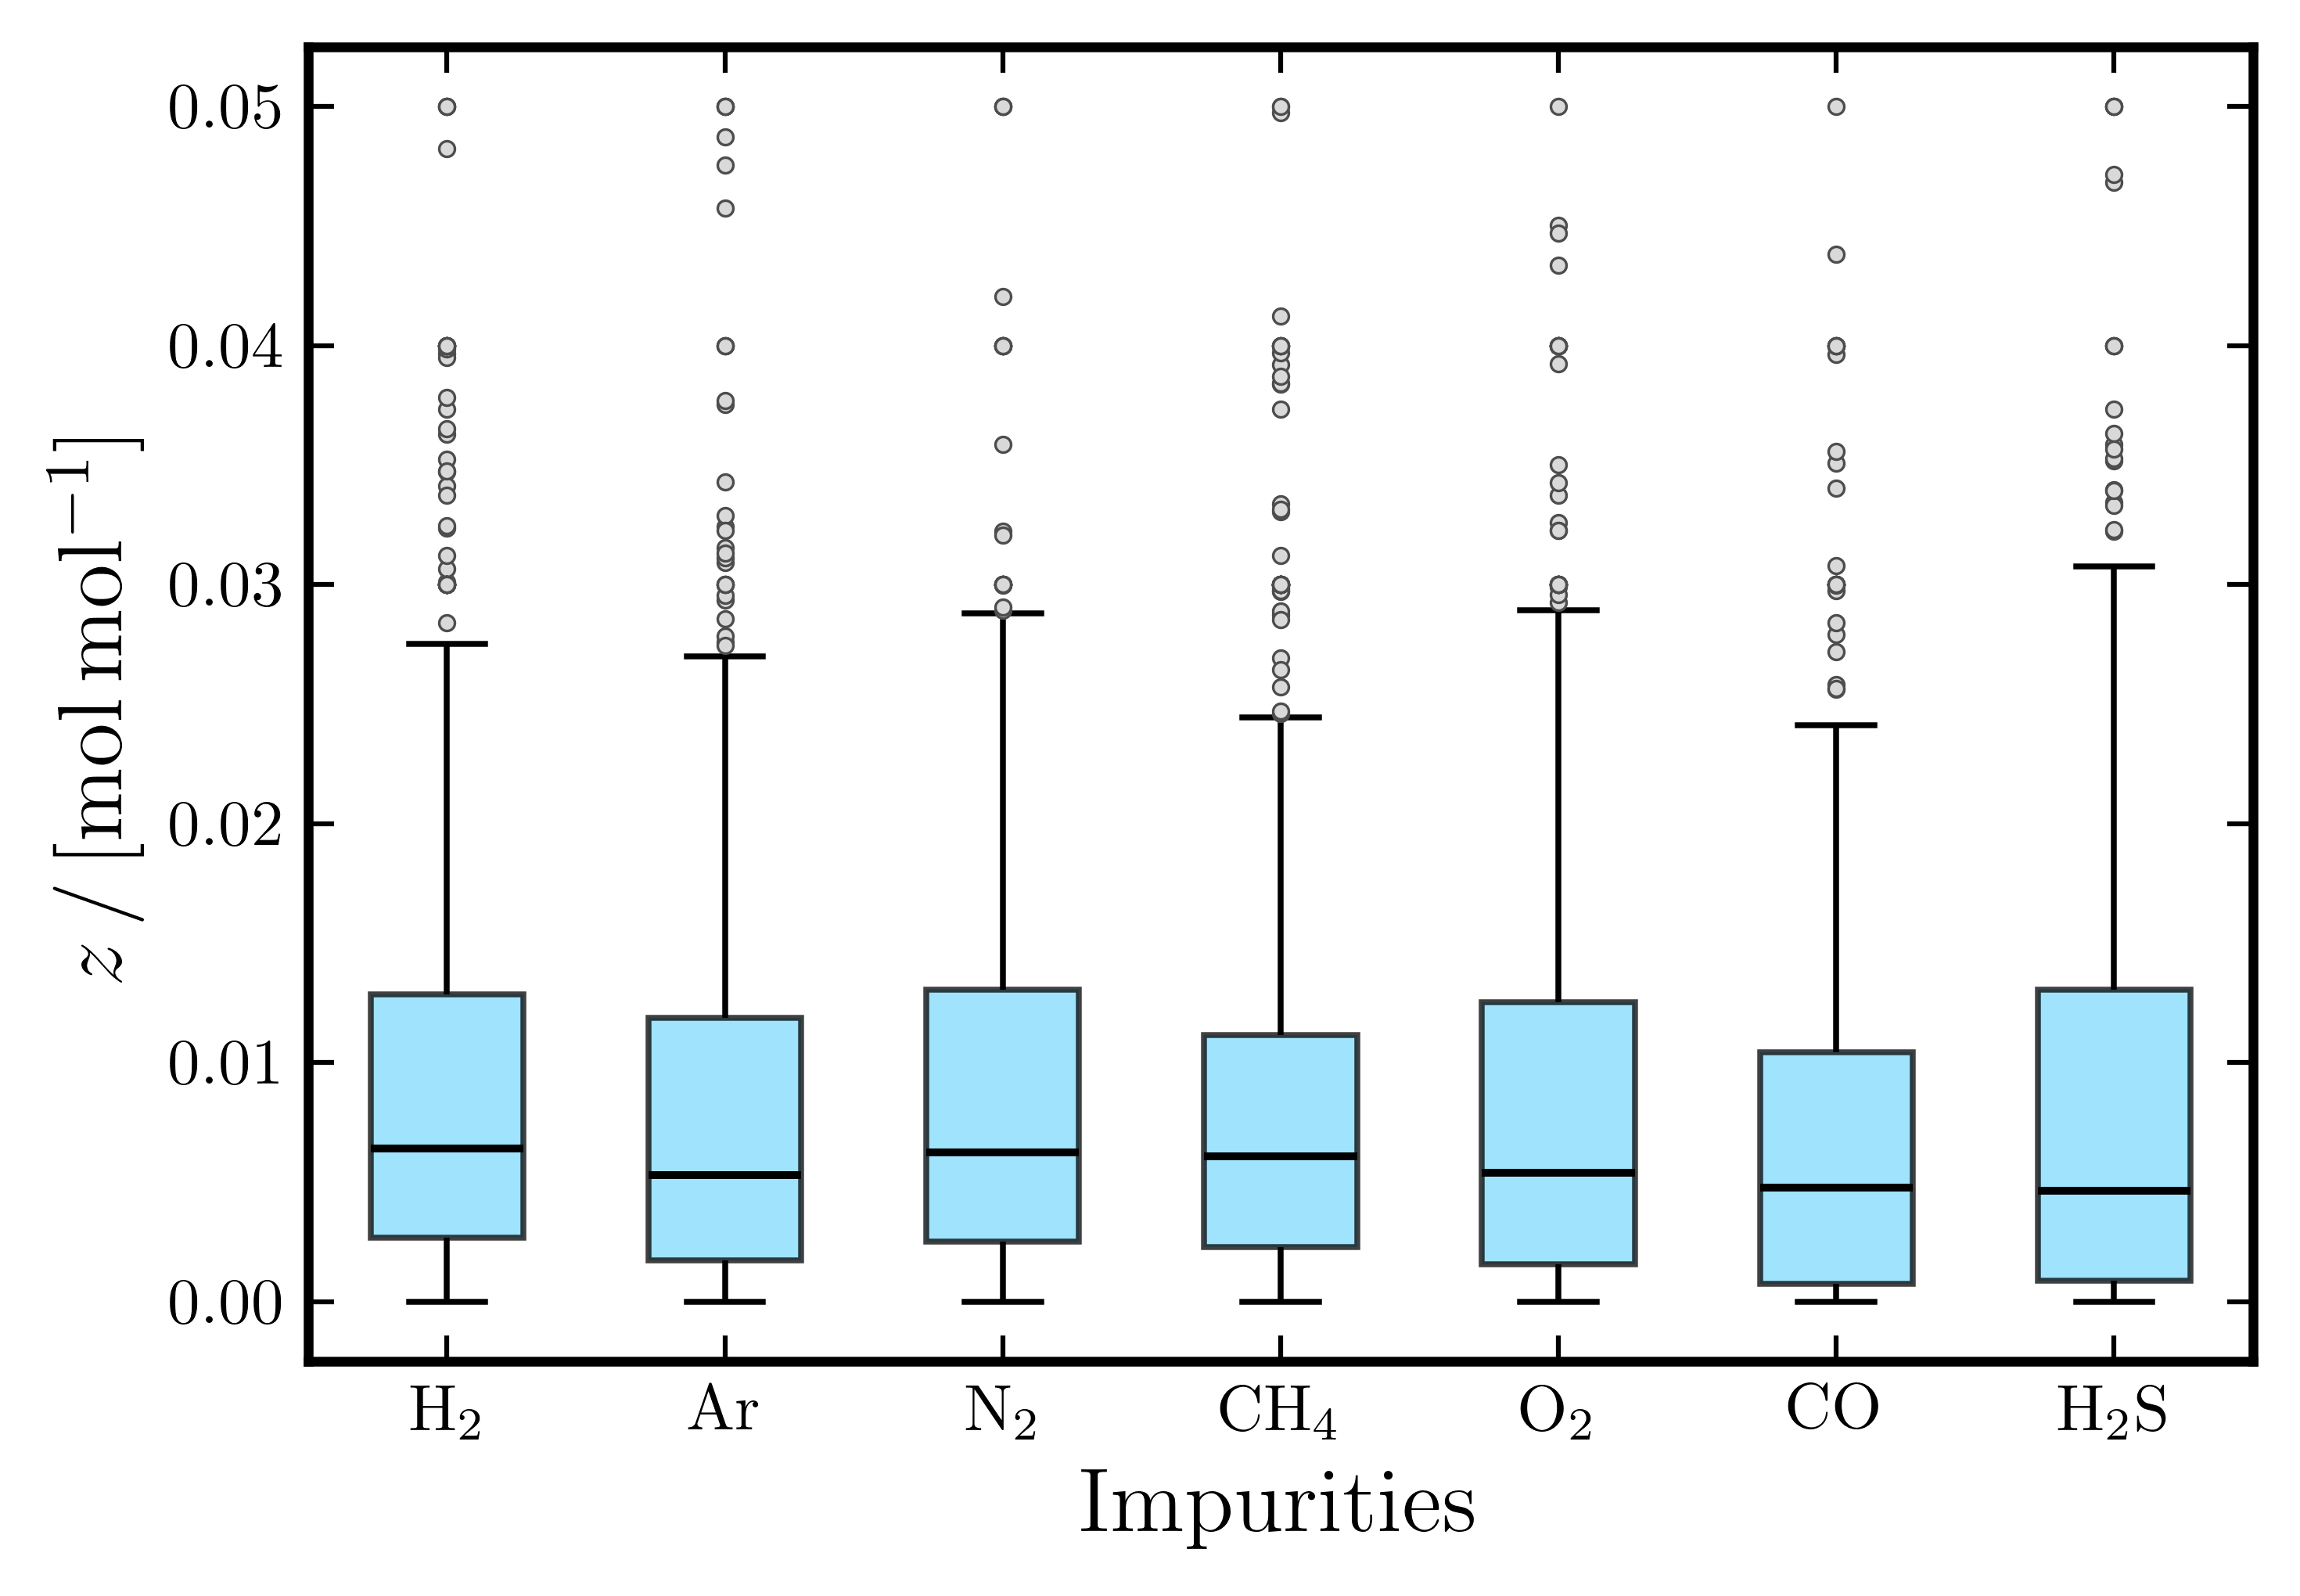

In [16]:
# ── Diagnostic plots ──────────────────────────────────────────────────────────
# Map raw feed_source values → display labels used in src_order / src_labels.
plot_src = df_comp["feed_source"].replace({
    "Random (Dirichlet)": "Dirichlet distribution",
    "Systematic":         "Systematic scaling",
    "industrial_bound":   "Industrial feeds",
    "industrial_range":   "Industrial feeds",
})

# Shared fill colour — matches the "Dirichlet distribution" hue in the
# minor-components-by-source boxplot below.
FILL_COLOR = "#81dafd"

# Shared flier (outlier) style — matches the by-source boxplot below.
# markeredgewidth=0.4 → thin edge ring, consistent across all plots.
FLIER_PROPS = dict(
    marker="o",
    markerfacecolor="#d9d9d9",
    markeredgecolor="#4d4d4d",
    markeredgewidth=0.4,
    markersize=ps.markersize * 0.6,
    linestyle="none",
)

# ── Plot 1 : Minor component distributions ────────────────────────────────────
minor_cols = ["H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
plot_df    = df_comp[minor_cols].melt(var_name="Component", value_name="Mole fraction")
plot_df    = plot_df[plot_df["Mole fraction"] > 0]

fig1, ax1 = ps.plot_init(w=5, h=3.5)
sns.boxplot(
    data=plot_df, x="Component", y="Mole fraction", ax=ax1,
    width=0.55,
    linewidth=ps.spine_width * 0.6,
    fliersize=ps.markersize * 0.6,
    boxprops=dict(facecolor=FILL_COLOR, edgecolor="black", alpha=0.75),
    medianprops=dict(color="black", linewidth=ps.spine_width * 0.8),
    whiskerprops=dict(color="black", linewidth=ps.spine_width * 0.6),
    capprops=dict(color="black", linewidth=ps.spine_width * 0.6),
    flierprops=FLIER_PROPS,
)

ax1.set_xticklabels(
    [r"$" + ps.component_to_latex(c) + r"$" for c in minor_cols],
    fontsize=ps.tick_labelsize,
)
ax1.set_xlabel(r"$\mathrm{Impurities}$", fontsize=ps.label_fontsize)
ax1.set_ylabel(r"$z \, / \, [\mathrm{mol \, mol^{-1}}]$", fontsize=ps.label_fontsize)
ax1.tick_params(axis="both", which="major", labelsize=ps.tick_labelsize)
ax1.set_axisbelow(True)

plt.tight_layout()
ps.save_plot(fig1, "pool_minor_components", folder=str(OUTPUT_DIR))
plt.show()

/tmp/ipykernel_371491/171224135.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(src_labels, fontsize=ps.tick_labelsize)


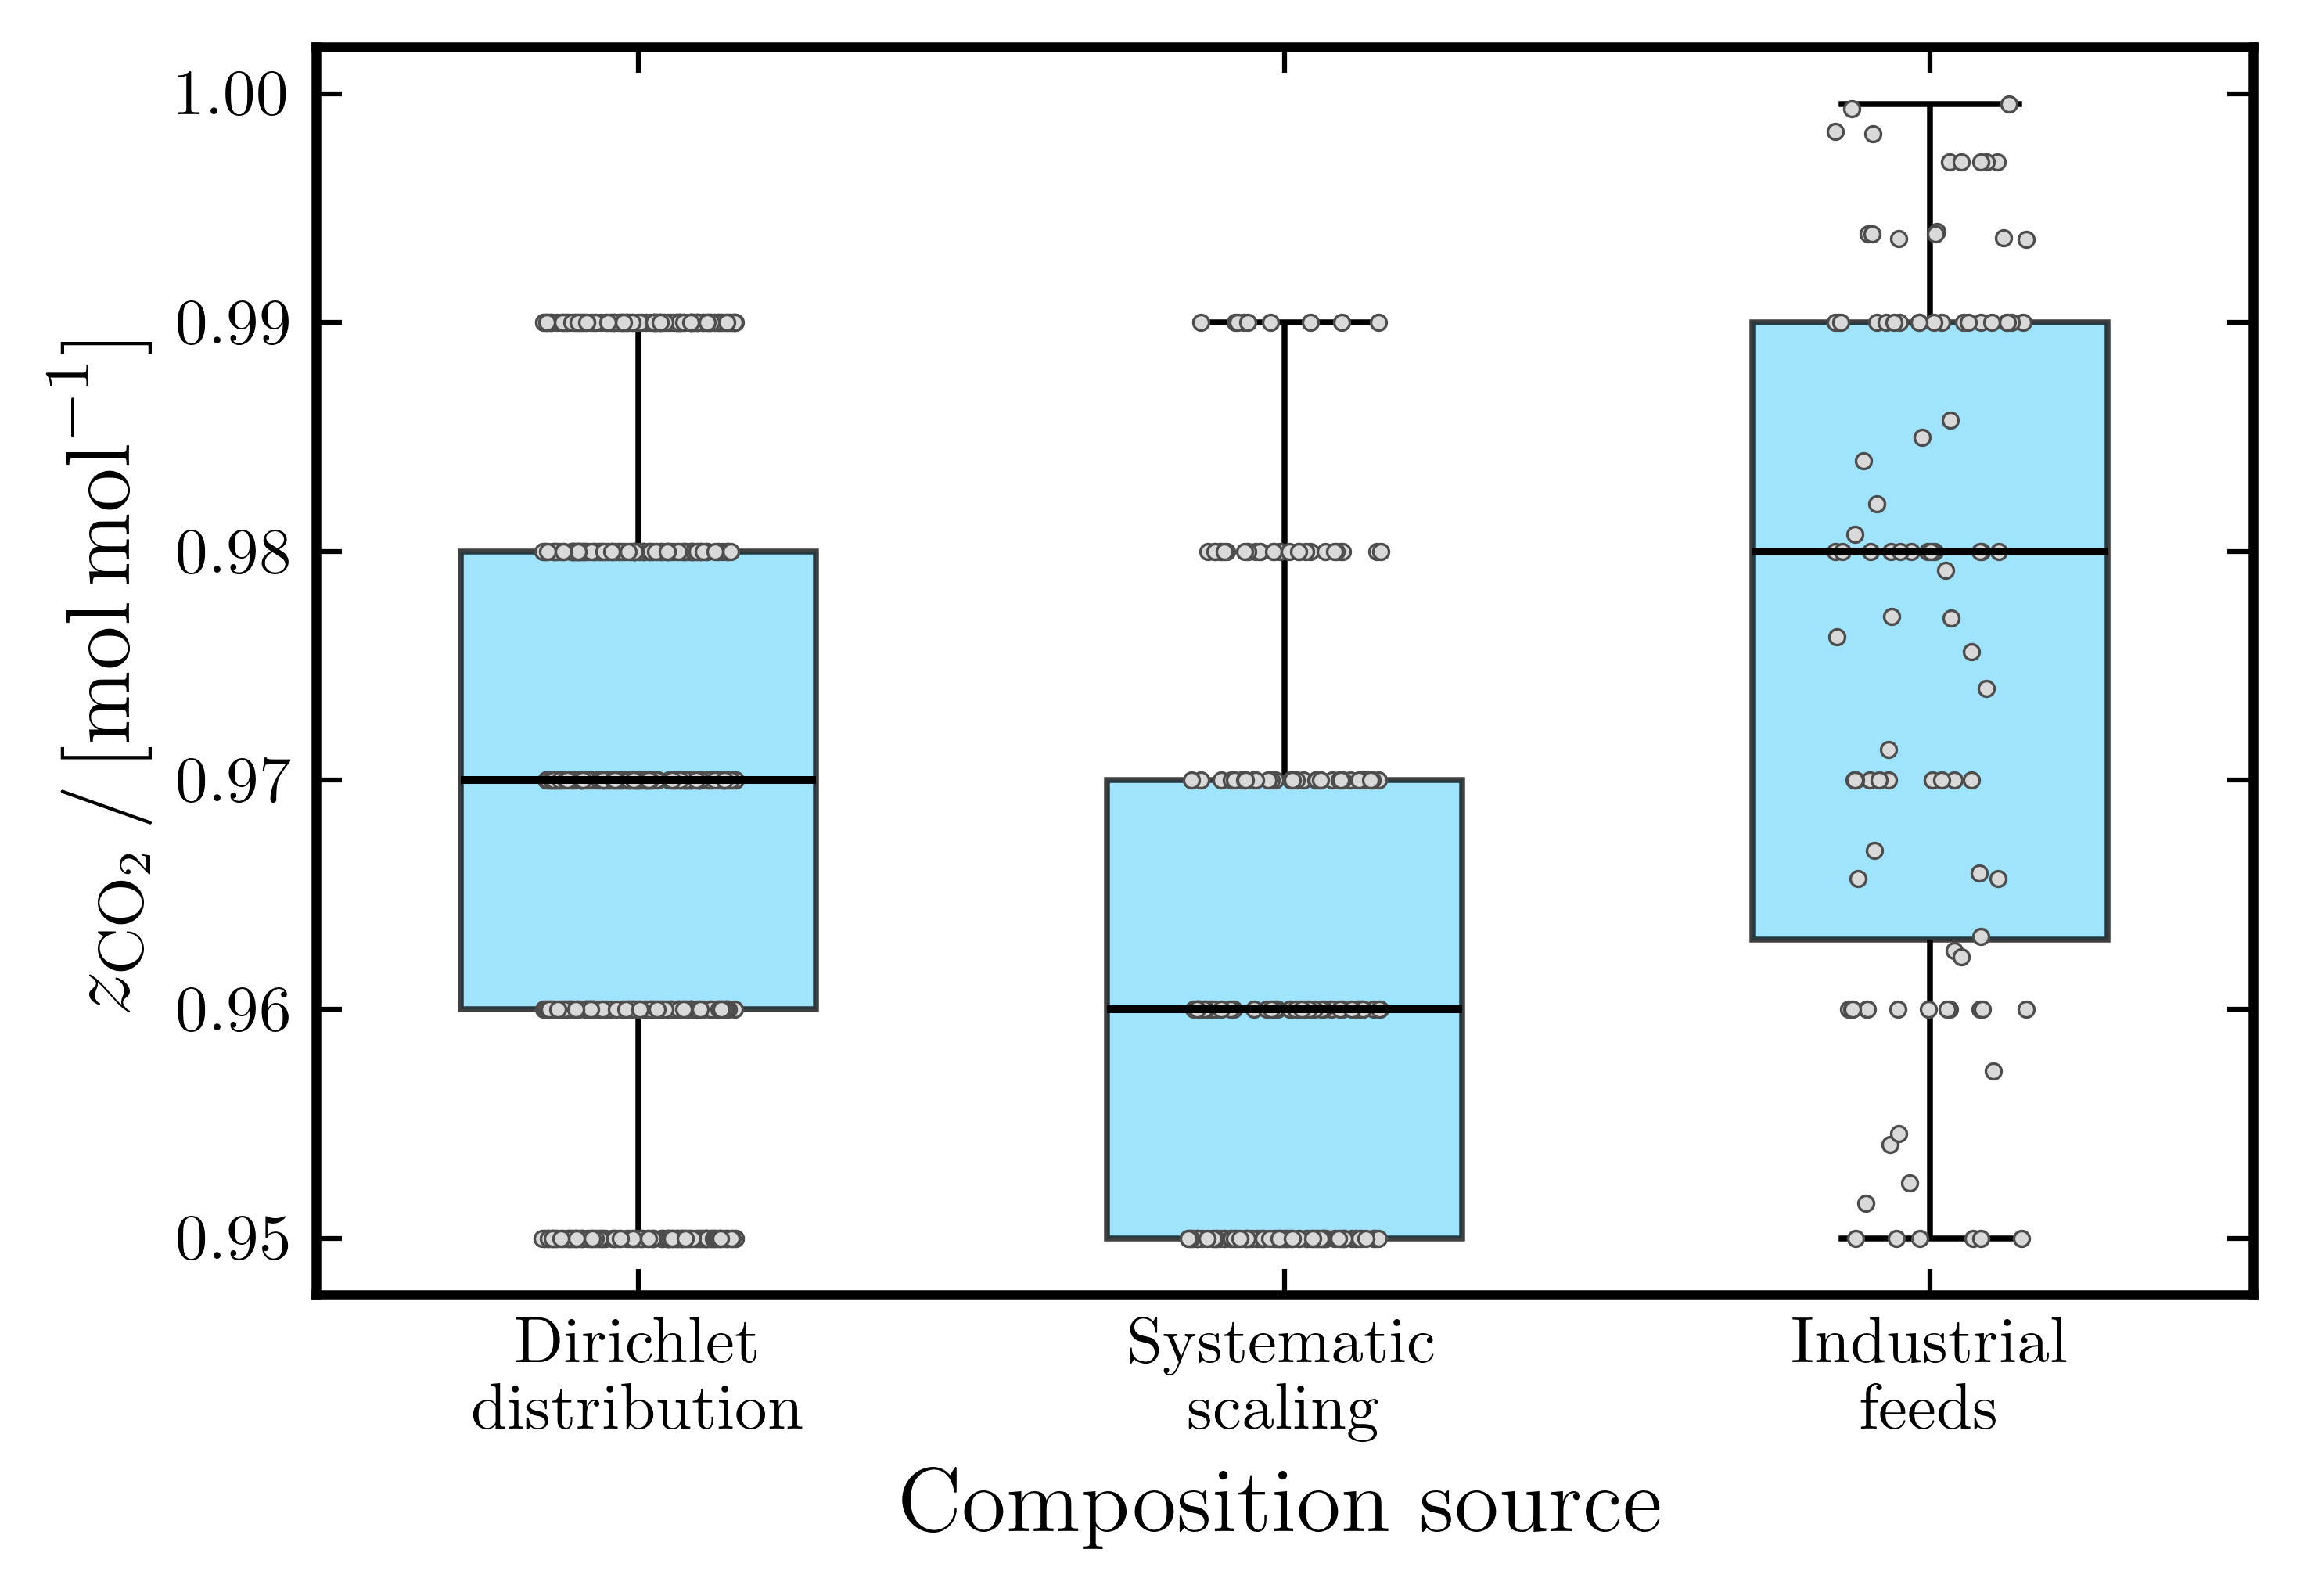

Mixture size distribution:
mixture_size
2     46
3    142
4    345
5    218
6    144
7     33
8     72
Name: count, dtype: int64

Feed source distribution:
feed_source
Random (Dirichlet)    700
Systematic            200
industrial_bound       60
industrial_range       40
Name: count, dtype: int64


In [17]:
# ── Plot 2 : CO2 mole fraction by feed source ─────────────────────────────────
src_order = ["Dirichlet distribution", "Systematic scaling", "Industrial feeds"]

src_labels = [
    r"$\mathrm{Dirichlet}$" + "\n" + r"$\mathrm{distribution}$",
    r"$\mathrm{Systematic}$" + "\n" + r"$\mathrm{scaling}$",
    r"$\mathrm{Industrial}$" + "\n" + r"$\mathrm{feeds}$",
]

co2_df = pd.DataFrame({
    "CO2": df_comp["CO2"],
    "feed_source": plot_src
})

fig2, ax2 = ps.plot_init(w=5, h=3.5)

sns.boxplot(
    data=co2_df,
    x="feed_source",
    y="CO2",
    ax=ax2,
    order=src_order,
    width=0.55,
    linewidth=ps.spine_width * 0.6,
    fliersize=ps.markersize * 0.6,
    boxprops=dict(facecolor=FILL_COLOR, edgecolor="black", alpha=0.75),
    medianprops=dict(color="black", linewidth=ps.spine_width * 0.8),
    whiskerprops=dict(color="black", linewidth=ps.spine_width * 0.6),
    capprops=dict(color="black", linewidth=ps.spine_width * 0.6),
    flierprops=FLIER_PROPS,
)

# Individual data points — match the flier (outlier) marker style of the other
# plots: filled #d9d9d9 with #4d4d4d edges, same thin edge (0.4 pt) as FLIER_PROPS.
sns.stripplot(
    data=co2_df,
    x="feed_source",
    y="CO2",
    ax=ax2,
    order=src_order,
    marker="o",
    facecolor="#d9d9d9",
    edgecolor="#4d4d4d",
    linewidth=0.4,
    size=ps.markersize * 0.6,
    jitter=0.15,
    zorder=2,
)

ax2.set_xticklabels(src_labels, fontsize=ps.tick_labelsize)
ax2.set_xlabel(r"$\mathrm{Composition\ source}$", fontsize=ps.label_fontsize)

ax2.set_ylabel(
    ps.label_map.get(
        "z_co2",
        r"$z_{\mathrm{CO_2}} \, / \, [\mathrm{mol \, mol^{-1}}]$"
    ),
    fontsize=ps.label_fontsize
)

ax2.tick_params(axis="both", which="major", labelsize=ps.tick_labelsize)

# Elegant horizontal grid
# ax2.grid(axis="y", linestyle="--", alpha=0.35)
ax2.set_axisbelow(True)

plt.tight_layout()
ps.save_plot(fig2, "pool_co2_by_source", folder=str(OUTPUT_DIR))
plt.show()

print("Mixture size distribution:")
print(df_comp["mixture_size"].value_counts().sort_index())

print("\nFeed source distribution:")
print(df_comp["feed_source"].value_counts())

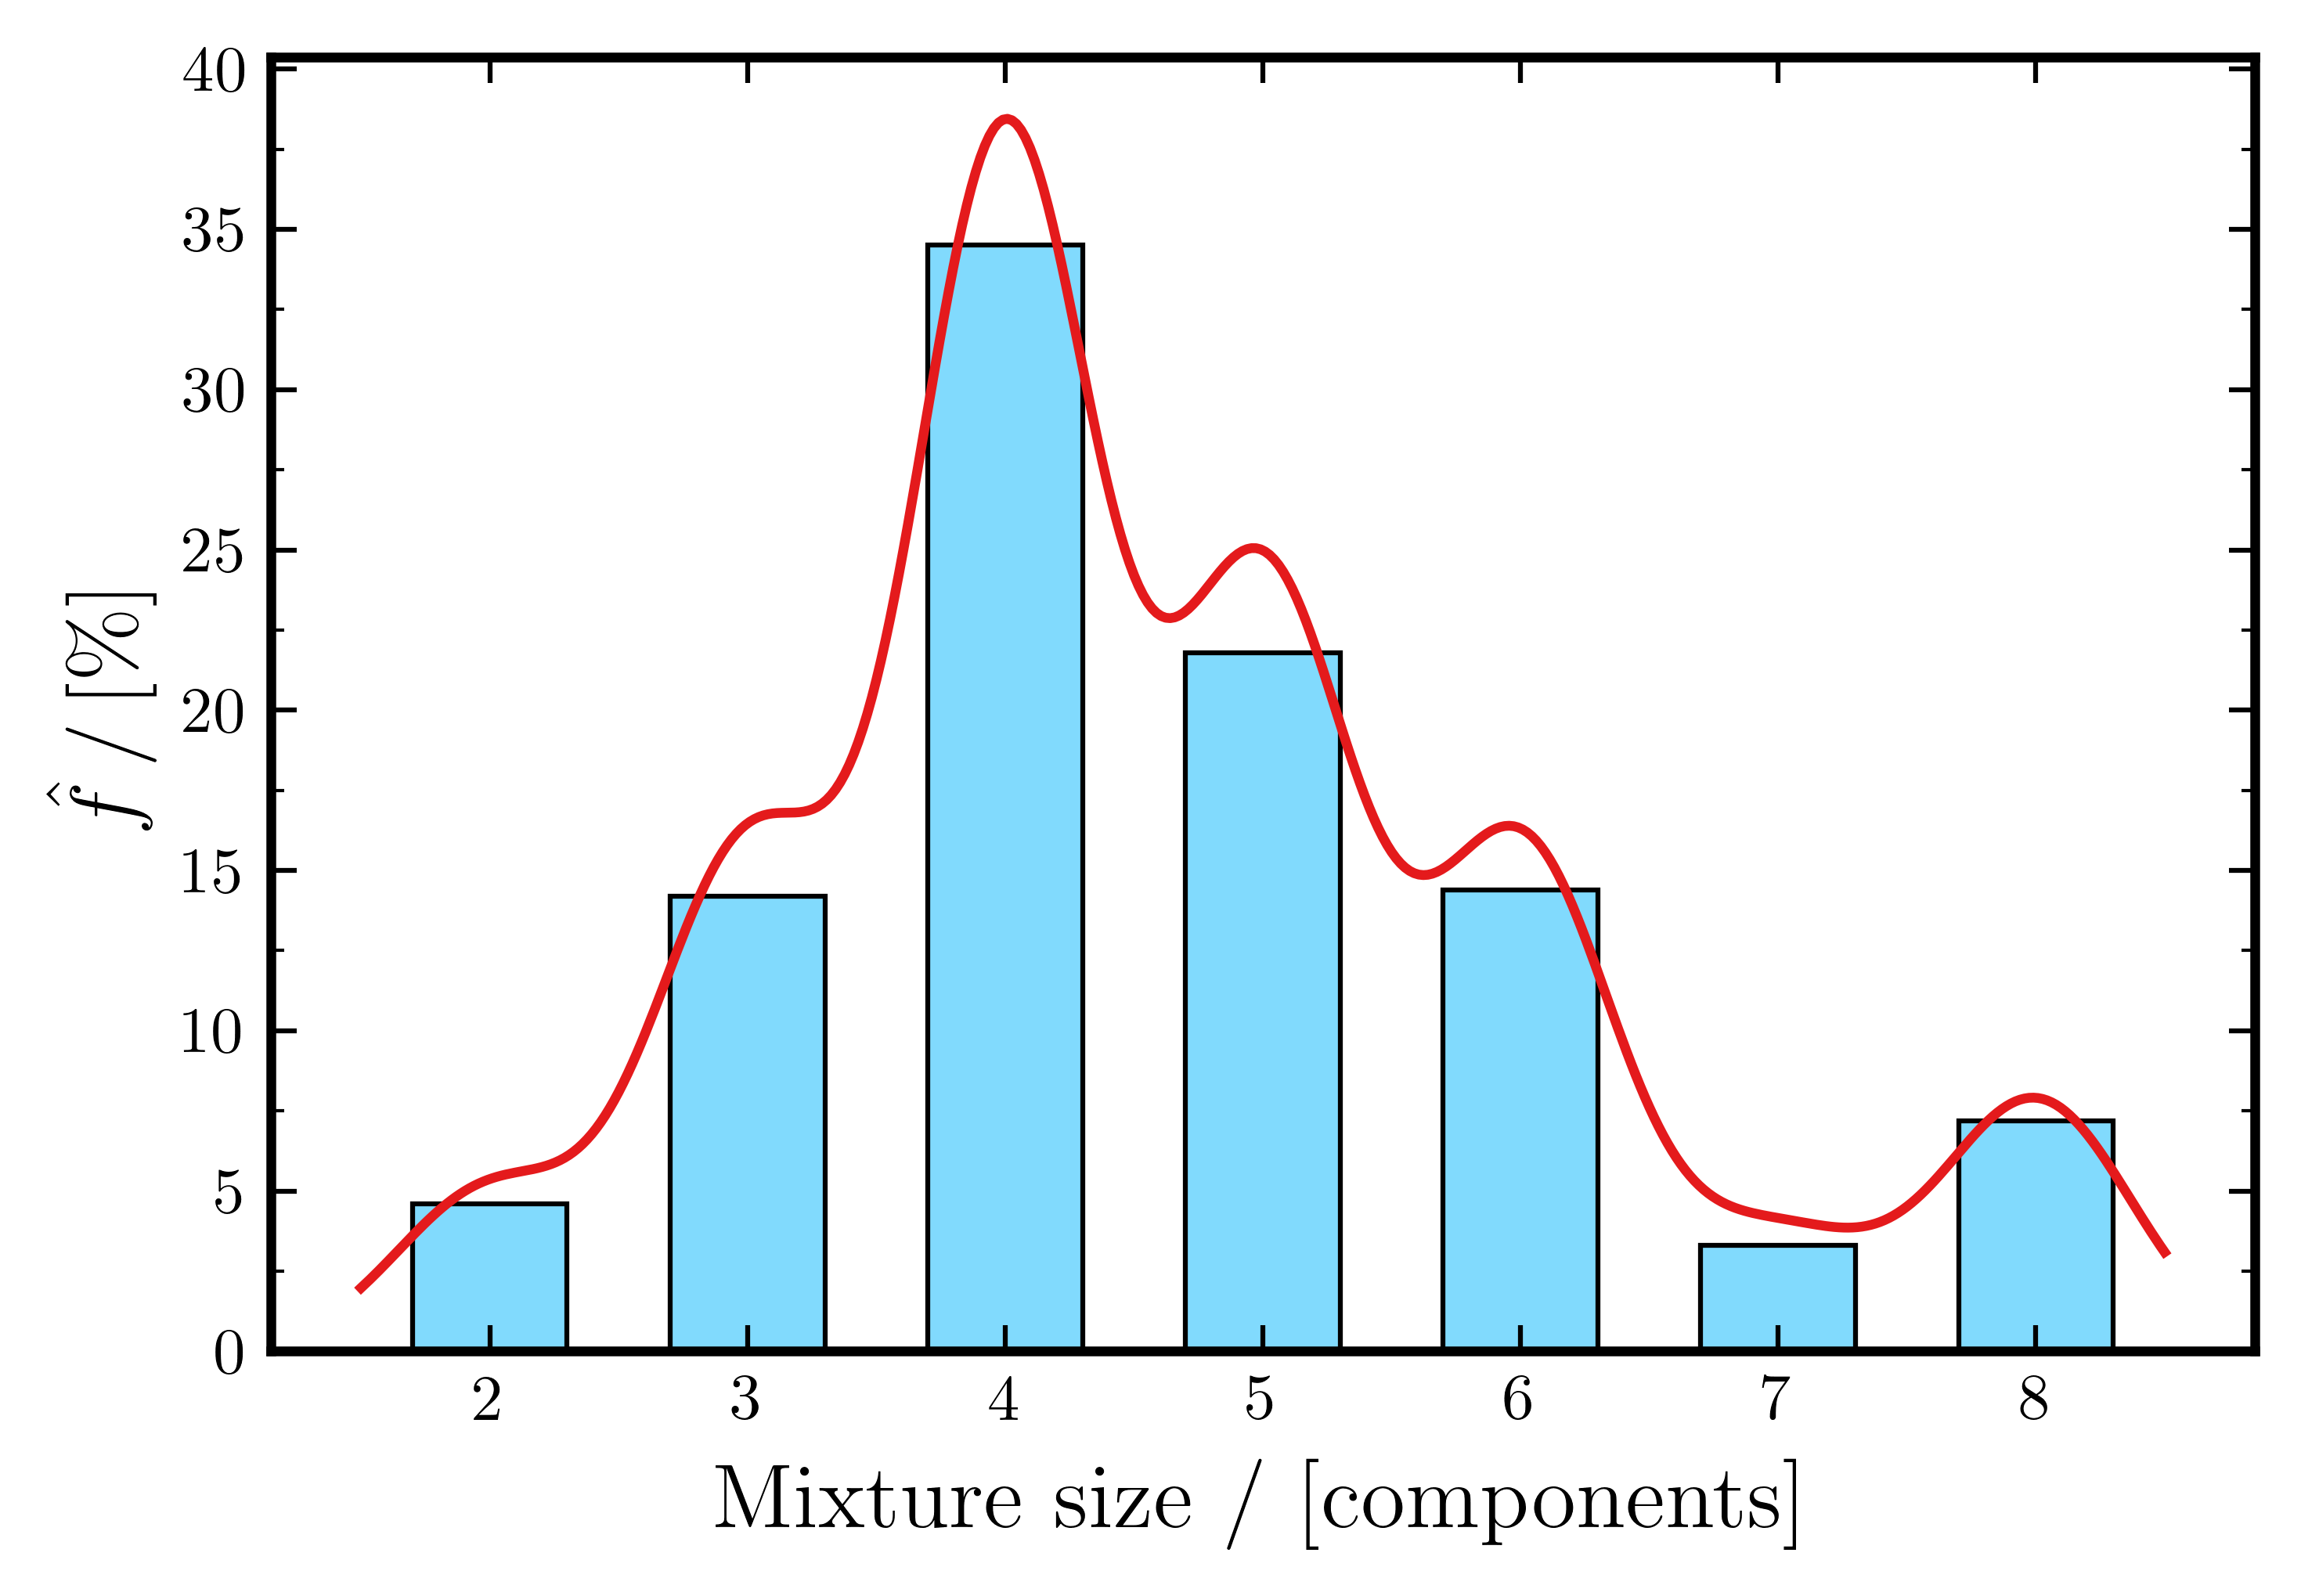

In [18]:
# ── Mixture size distribution histogram + KDE ─────────────────────────────────
# Normalisation:
#   bar  : h_hat_i [%] = ( n_i / N ) × 100   →  all bars sum to 100 %
#   KDE  : f_hat(x) [%] = f_KDE(x) × 100     →  integral over domain = 100 %
from scipy.stats import gaussian_kde
from matplotlib.ticker import AutoMinorLocator, NullLocator

mix_sizes   = df_comp["mixture_size"]
size_counts = mix_sizes.value_counts().sort_index()
N           = len(mix_sizes)

pct_counts = (size_counts / N) * 100

kde          = gaussian_kde(mix_sizes, bw_method="scott")
x_kde        = np.linspace(mix_sizes.min() - 0.5, mix_sizes.max() + 0.5, 400)
kde_vals_pct = kde(x_kde) * 100

fig, ax = ps.plot_init(w=5, h=3.5)

ax.bar(
    size_counts.index, pct_counts,
    width=0.6,
    color="#81dafd",
    edgecolor="black",
    linewidth=ps.spine_width * 0.5,
)
ax.plot(x_kde, kde_vals_pct, color=ps.colors[0], linewidth=ps.linewidth * 1.5)

ax.set_xlabel(r"$\mathrm{Mixture\ size\ /\ [components]}$",
              fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\hat{f} \, / \, [\%]$", fontsize=ps.label_fontsize)
ax.set_xticks(size_counts.index)

# Minor ticks: y-axis only — x-axis is discrete (integer component counts)
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="major", labelsize=ps.tick_labelsize)

plt.tight_layout()
ps.save_plot(fig, "pool_mixture_size_dist", folder=str(OUTPUT_DIR))
plt.show()

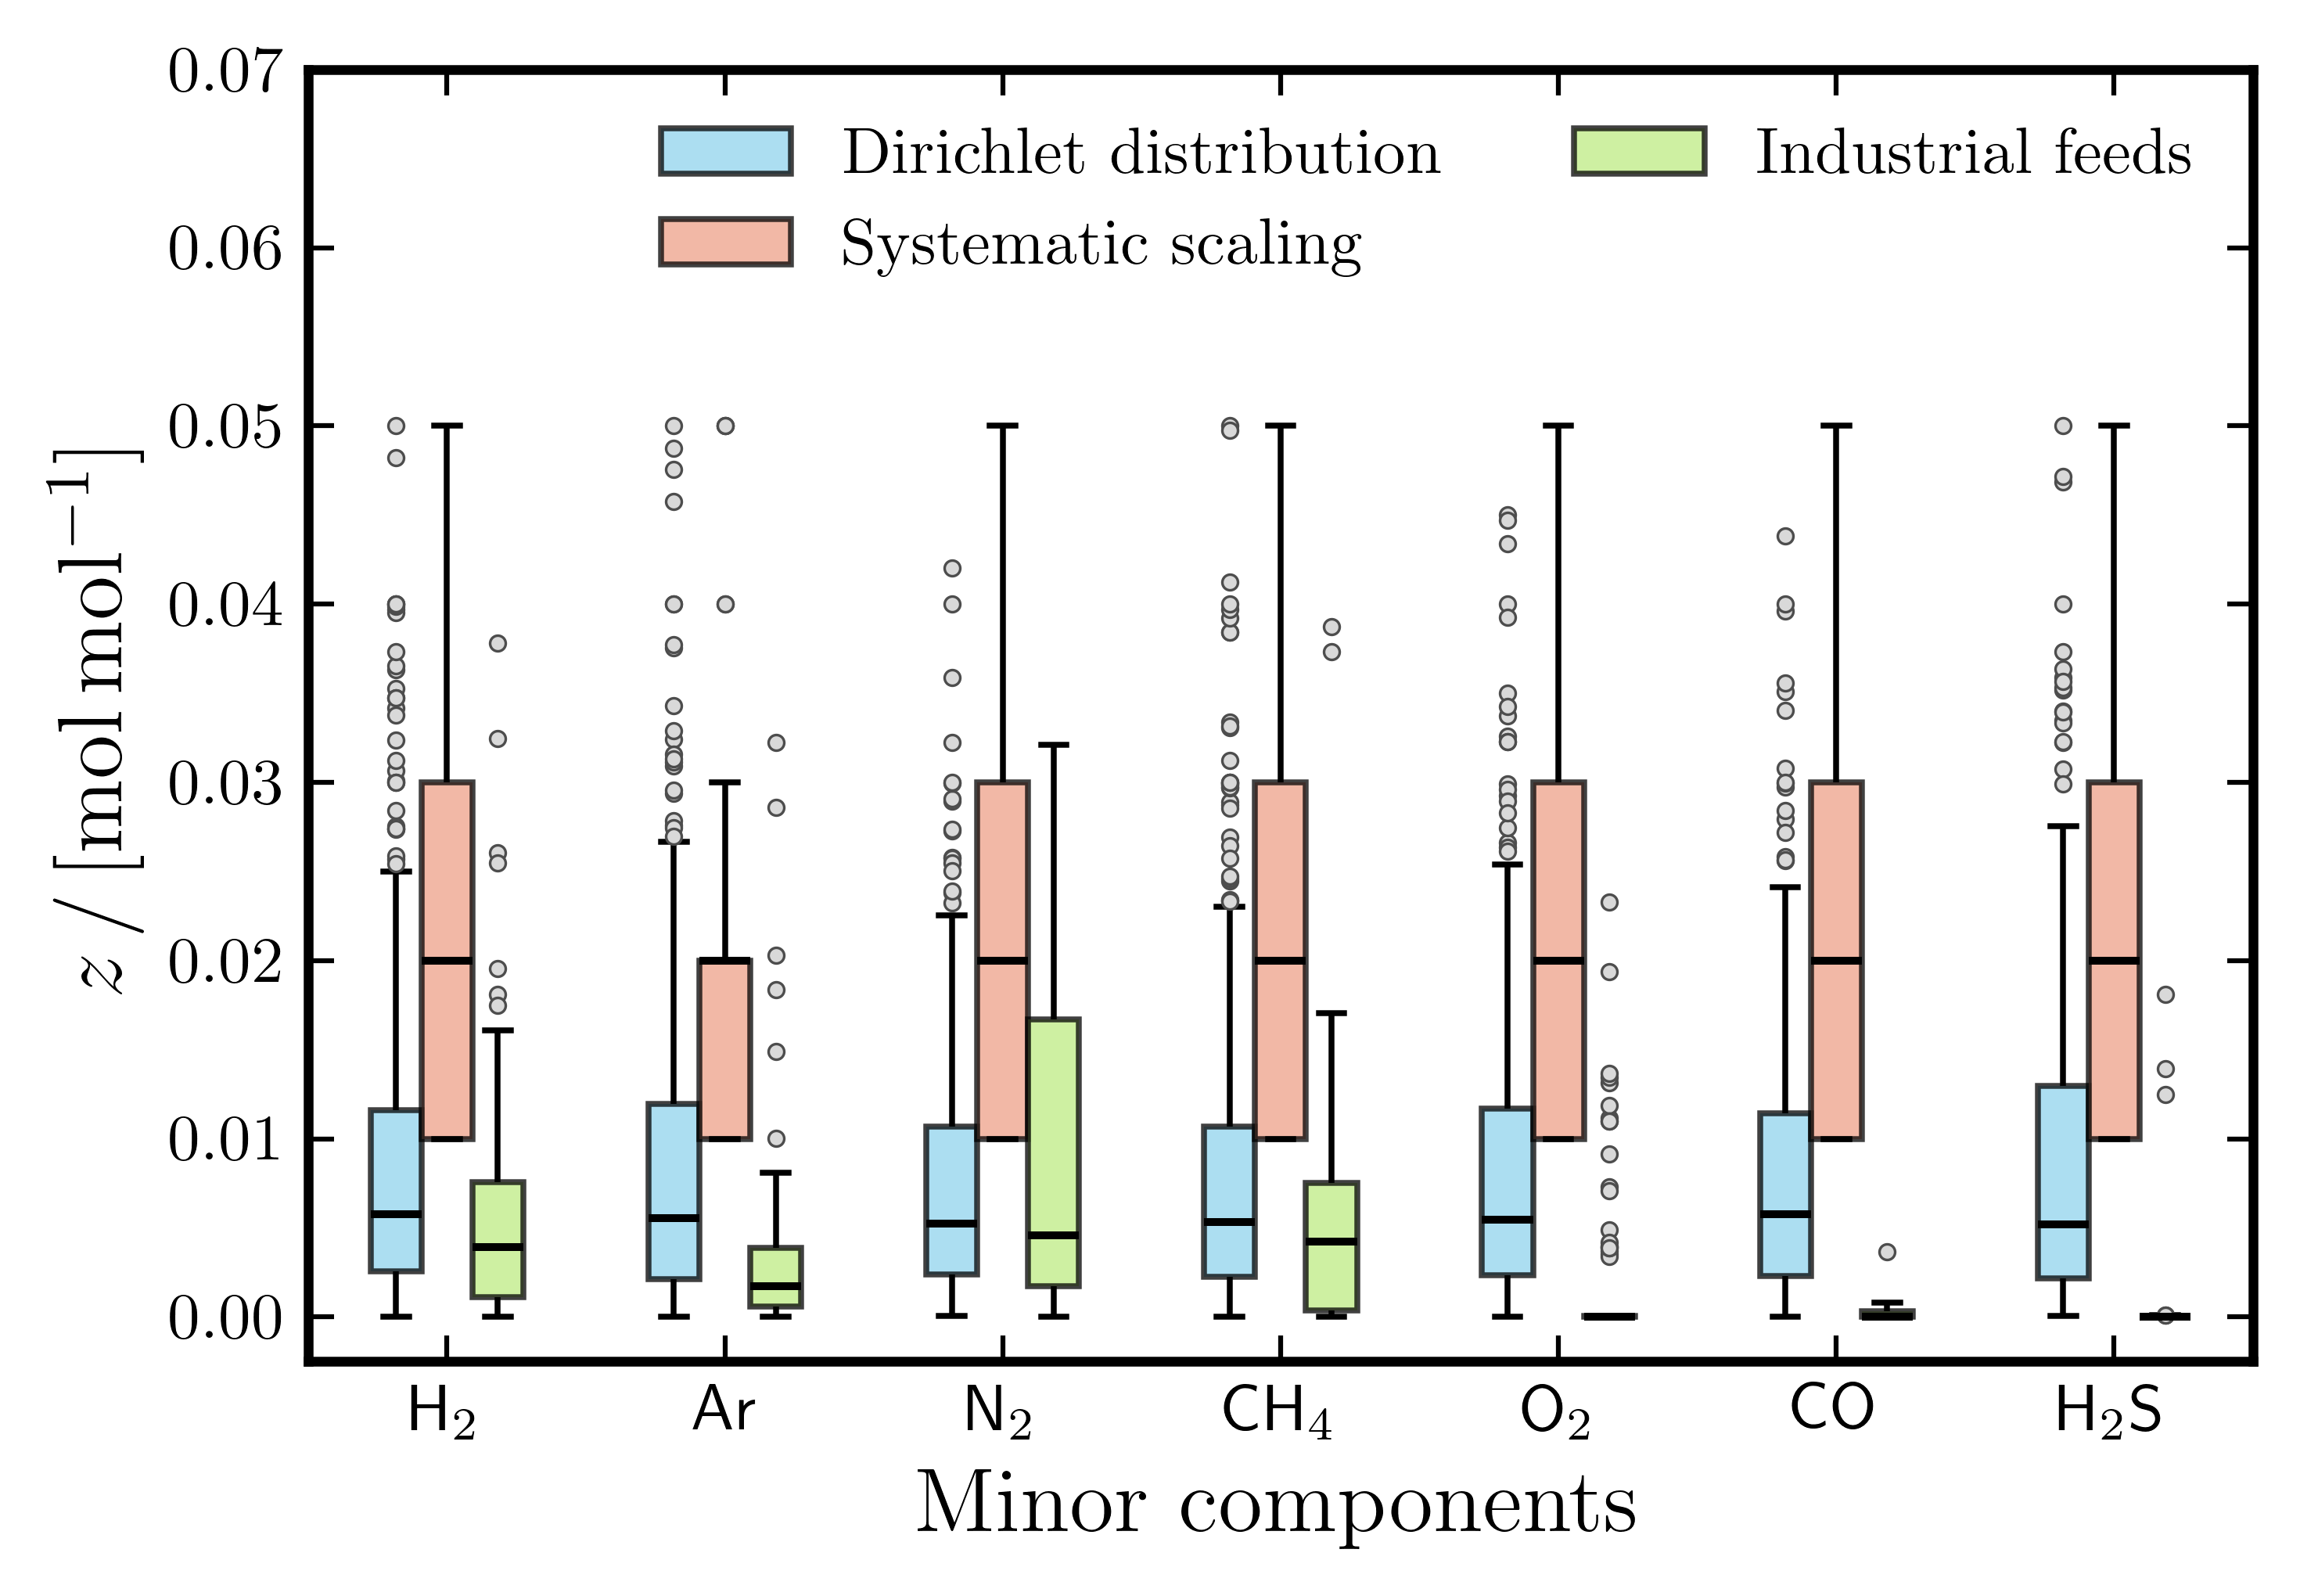

In [19]:
# ── Distribution of minor components by feed source ───────────────────────────
palette = ["#81dafd", "#ff9778", "#c0fc72"]

minor_cols = ['H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']

# Build the working dataframe from df_comp; same label convention as Plot 2
# in al_pool_07_plots (the two industrial sub-sources collapse into one label).
# Labels are LaTeX-wrapped so they render with \mathrm{} in the legend.
df = df_comp.copy()
df["feed_source_plot"] = df["feed_source"].replace({
    "Random (Dirichlet)": r"$\mathrm{Dirichlet\ distribution}$",
    "Systematic":         r"$\mathrm{Systematic\ scaling}$",
    "industrial_bound":   r"$\mathrm{Industrial\ feeds}$",
    "industrial_range":   r"$\mathrm{Industrial\ feeds}$",
})

plot_df = df[['feed_source_plot'] + minor_cols].copy()
plot_df = plot_df.melt(
    id_vars='feed_source_plot',
    value_vars=minor_cols,
    var_name='Component',
    value_name='Mole fraction'
)
plot_df = plot_df[plot_df["Mole fraction"] > 0]

rename_map = {
    "H2":  r"H$_2$",
    "Ar":  r"Ar",
    "N2":  r"N$_2$",
    "CH4": r"CH$_4$",
    "O2":  r"O$_2$",
    "CO":  r"CO",
    "H2S": r"H$_2$S",
}
plot_df["Component"] = plot_df["Component"].map(rename_map)

hue_order = [
    r"$\mathrm{Dirichlet\ distribution}$",
    r"$\mathrm{Systematic\ scaling}$",
    r"$\mathrm{Industrial\ feeds}$",
]

fig, ax = ps.plot_init(w=5, h=3.5)

sns.boxplot(
    data=plot_df,
    x="Component",
    y="Mole fraction",
    hue="feed_source_plot",
    hue_order=hue_order,
    ax=ax,
    palette=palette,
    linewidth=ps.spine_width * 0.6,
    fliersize=ps.markersize * 0.6,
    width=0.55,
    boxprops=dict(edgecolor='black', alpha=0.75),
    whiskerprops=dict(color='black', linewidth=ps.spine_width * 0.6),
    capprops=dict(color='black', linewidth=ps.spine_width * 0.6),
    medianprops=dict(color='black', linewidth=ps.spine_width * 0.8),
    flierprops=dict(
        marker='o',
        markerfacecolor='#d9d9d9',
        markeredgecolor='#4d4d4d',
        markeredgewidth=0.4,
        markersize=ps.markersize * 0.6,
        linestyle='none',
    ),
)

# ax.axhline(0.05, color='gray', linestyle='--', linewidth=ps.spine_width * 0.5)
ax.set_xlabel(r"$\mathrm{Minor\ components}$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$z \, / \, [\mathrm{mol \, mol^{-1}}]$",
              fontsize=ps.label_fontsize)
ax.tick_params(axis="both", which="major", labelsize=ps.tick_labelsize)
ax.set_axisbelow(True)

ax.legend(fontsize=ps.tick_labelsize, loc="upper right", ncol=2,
          edgecolor="black", facecolor="white", frameon=False, framealpha=1.0)
ax.set_ylim(top=0.07)
plt.tight_layout()
ps.save_plot(fig, "boxplot_minor_components", folder=str(OUTPUT_DIR))
plt.show()

In [20]:
elapsed = time.perf_counter() - notebook_start
print(f"Notebook runtime: {elapsed:.1f} s")

Notebook runtime: 14.7 s
